# Choosing `k` for daily outlier removal

Compare the IQR rule with `k = 1.5`, `k = 2`, and `k = 3` for `ABVERKAUFTE_MENGE`.

Outliers are computed per (`ARTIKEL_ID`, `MARKT_ID`) series from `data/interim/transactions_daily_agg`.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data" / "interim" / "transactions_daily_agg").exists():
        ROOT = candidate
        break

DATA_DIR = ROOT / "data" / "interim" / "transactions_daily_agg"
DATA_GLOB = DATA_DIR / "transactions_year_*.parquet"
DEMAND_COL = "ABVERKAUFTE_MENGE"
TOP_N = 10

files = sorted(DATA_DIR.glob("transactions_year_*.parquet"))
if not files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")

def sql_literal(value):
    return "'" + str(value).replace("'", "''") + "'"

con = duckdb.connect()
con.execute("PRAGMA threads=8")

print(f"Reading {len(files)} yearly parquet files from {DATA_DIR}")

Reading 6 yearly parquet files from /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/transactions_daily_agg


In [2]:
con.execute(
    f"""
    CREATE OR REPLACE TEMP VIEW source AS
    SELECT *, CAST(DATE AS DATE) AS DATE_D
    FROM read_parquet({sql_literal(DATA_GLOB)})
    """
)

columns = [row[0] for row in con.execute("DESCRIBE SELECT * FROM source").fetchall()]
requested_cols = [
    "ARTIKEL_ID",
    "MARKT_ID",
    "VERKAUFSEINHEIT",
    "ARTIKEL_BEZ",
    "UMS_MENGE",
    "GRAMM_BON",
    "DATE",
    DEMAND_COL,
]
available_cols = [col for col in requested_cols if col in columns]
missing_cols = [col for col in requested_cols if col not in columns]

if missing_cols:
    print("Requested columns not present in the daily aggregate files:", missing_cols)

available_cols

Requested columns not present in the daily aggregate files: ['GRAMM_BON']


['ARTIKEL_ID',
 'MARKT_ID',
 'VERKAUFSEINHEIT',
 'ARTIKEL_BEZ',
 'UMS_MENGE',
 'DATE',
 'ABVERKAUFTE_MENGE']

## Overall effect of `k = 1.5`, `k = 2`, and `k = 3`

In [3]:
con.execute(
    f"""
    CREATE OR REPLACE TEMP TABLE bounds AS
    WITH q AS (
        SELECT
            ARTIKEL_ID,
            MARKT_ID,
            quantile_cont({DEMAND_COL}, 0.25) AS q1,
            quantile_cont({DEMAND_COL}, 0.75) AS q3
        FROM source
        GROUP BY ARTIKEL_ID, MARKT_ID
    )
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        q1,
        q3,
        q3 - q1 AS iqr,
        q3 + 1.5 * (q3 - q1) AS upper_k15,
        q3 + 2 * (q3 - q1) AS upper_k2,
        q3 + 3 * (q3 - q1) AS upper_k3
    FROM q
    """
)

summary = con.execute(
    f"""
    SELECT
        COUNT(*) AS rows_total,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k15 THEN 1 ELSE 0 END) AS rows_removed_k15,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k2 THEN 1 ELSE 0 END) AS rows_removed_k2,
        SUM(CASE WHEN s.{DEMAND_COL} > b.upper_k3 THEN 1 ELSE 0 END) AS rows_removed_k3
    FROM source s
    JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
    """
).df()

summary["pct_removed_k15"] = summary["rows_removed_k15"] / summary["rows_total"] * 100
summary["pct_removed_k2"] = summary["rows_removed_k2"] / summary["rows_total"] * 100
summary["pct_removed_k3"] = summary["rows_removed_k3"] / summary["rows_total"] * 100
summary

,rows_total,rows_removed_k15,rows_removed_k2,rows_removed_k3,pct_removed_k15,pct_removed_k2,pct_removed_k3
0,49734237,3024102.0,2036618.0,1037481.0,6.080524,4.095002,2.08605


## Ten product/store series with the biggest outlier rows

The table keeps one biggest outlier row per (`ARTIKEL_ID`, `MARKT_ID`) series, ranked by the excess over the `k = 1.5` upper bound.

In [4]:
select_cols = ",\n            ".join(f"s.{col}" for col in available_cols)

top_outliers = con.execute(
    f"""
    WITH outlier_rows AS (
        SELECT
            {select_cols},
            b.q1,
            b.q3,
            b.iqr,
            b.upper_k15,
            b.upper_k2,
            b.upper_k3,
            s.{DEMAND_COL} - b.upper_k15 AS excess_k15,
            s.{DEMAND_COL} - b.upper_k2 AS excess_k2,
            s.{DEMAND_COL} - b.upper_k3 AS excess_k3,
            s.{DEMAND_COL} > b.upper_k15 AS outlier_k15,
            s.{DEMAND_COL} > b.upper_k2 AS outlier_k2,
            s.{DEMAND_COL} > b.upper_k3 AS outlier_k3,
            ROW_NUMBER() OVER (
                PARTITION BY s.ARTIKEL_ID, s.MARKT_ID
                ORDER BY s.{DEMAND_COL} - b.upper_k15 DESC
            ) AS series_rank
        FROM source s
        JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
        WHERE s.{DEMAND_COL} > b.upper_k15
    )
    SELECT * EXCLUDE (series_rank)
    FROM outlier_rows
    WHERE series_rank = 1
    ORDER BY excess_k15 DESC
    LIMIT {TOP_N}
    """
).df()

top_outliers

,ARTIKEL_ID,MARKT_ID,VERKAUFSEINHEIT,ARTIKEL_BEZ,UMS_MENGE,DATE,ABVERKAUFTE_MENGE,q1,q3,iqr,upper_k15,upper_k2,upper_k3,excess_k15,excess_k2,excess_k3,outlier_k15,outlier_k2,outlier_k3
0,316810,1200046,kg,Schweinenacken mit Knochen am Stück,801.846,2022-12-01,801.846,1.2960,22.778,21.4820,55.00100,65.742,87.2240,746.84500,736.104,714.6220,True,True,True
1,1107317,1800537,St,Grill- oder Rostbratwurst Stück,769.000,2023-04-29,769.000,5.0000,25.500,20.5000,56.25000,66.500,87.0000,712.75000,702.500,682.0000,True,True,True
2,316842,1300002,kg,Kasseler-Nacken am Stück,587.938,2024-11-28,587.938,1.3600,8.285,6.9250,18.67250,22.135,29.0600,569.26550,565.803,558.8780,True,True,True
3,316810,1300023,kg,Schweinenacken mit Knochen am Stück,685.733,2022-11-24,685.733,1.5305,55.859,54.3285,137.35175,164.516,218.8445,548.38125,521.217,466.8885,True,True,True
4,1097031,1250048,St,1/2 Belegte Brötchen,612.000,2025-05-30,612.000,30.0000,80.000,50.0000,155.00000,180.000,230.0000,457.00000,432.000,382.0000,True,True,True
5,1107317,1800039,St,Grill- oder Rostbratwurst Stück,434.000,2026-04-04,434.000,6.0000,25.000,19.0000,53.50000,63.000,82.0000,380.50000,371.000,352.0000,True,True,True
6,746457,1200046,kg,Falsches Filet vom Rind,377.345,2022-12-01,377.345,1.5210,6.776,5.2550,14.65850,17.286,22.5410,362.68650,360.059,354.8040,True,True,True
7,1107317,1800017,St,Grill- oder Rostbratwurst Stück,382.000,2025-04-19,382.000,6.0000,28.000,22.0000,61.00000,72.000,94.0000,321.00000,310.000,288.0000,True,True,True
8,1097031,1250071,St,1/2 Belegte Brötchen,377.000,2023-09-23,377.000,1.0000,33.000,32.0000,81.00000,97.000,129.0000,296.00000,280.000,248.0000,True,True,True
9,1004439,1800040,kg,Bratwurst Parade,316.000,2024-12-06,316.000,1.3580,10.000,8.6420,22.96300,27.284,35.9260,293.03700,288.716,280.0740,True,True,True


## Raw series vs after removing outliers

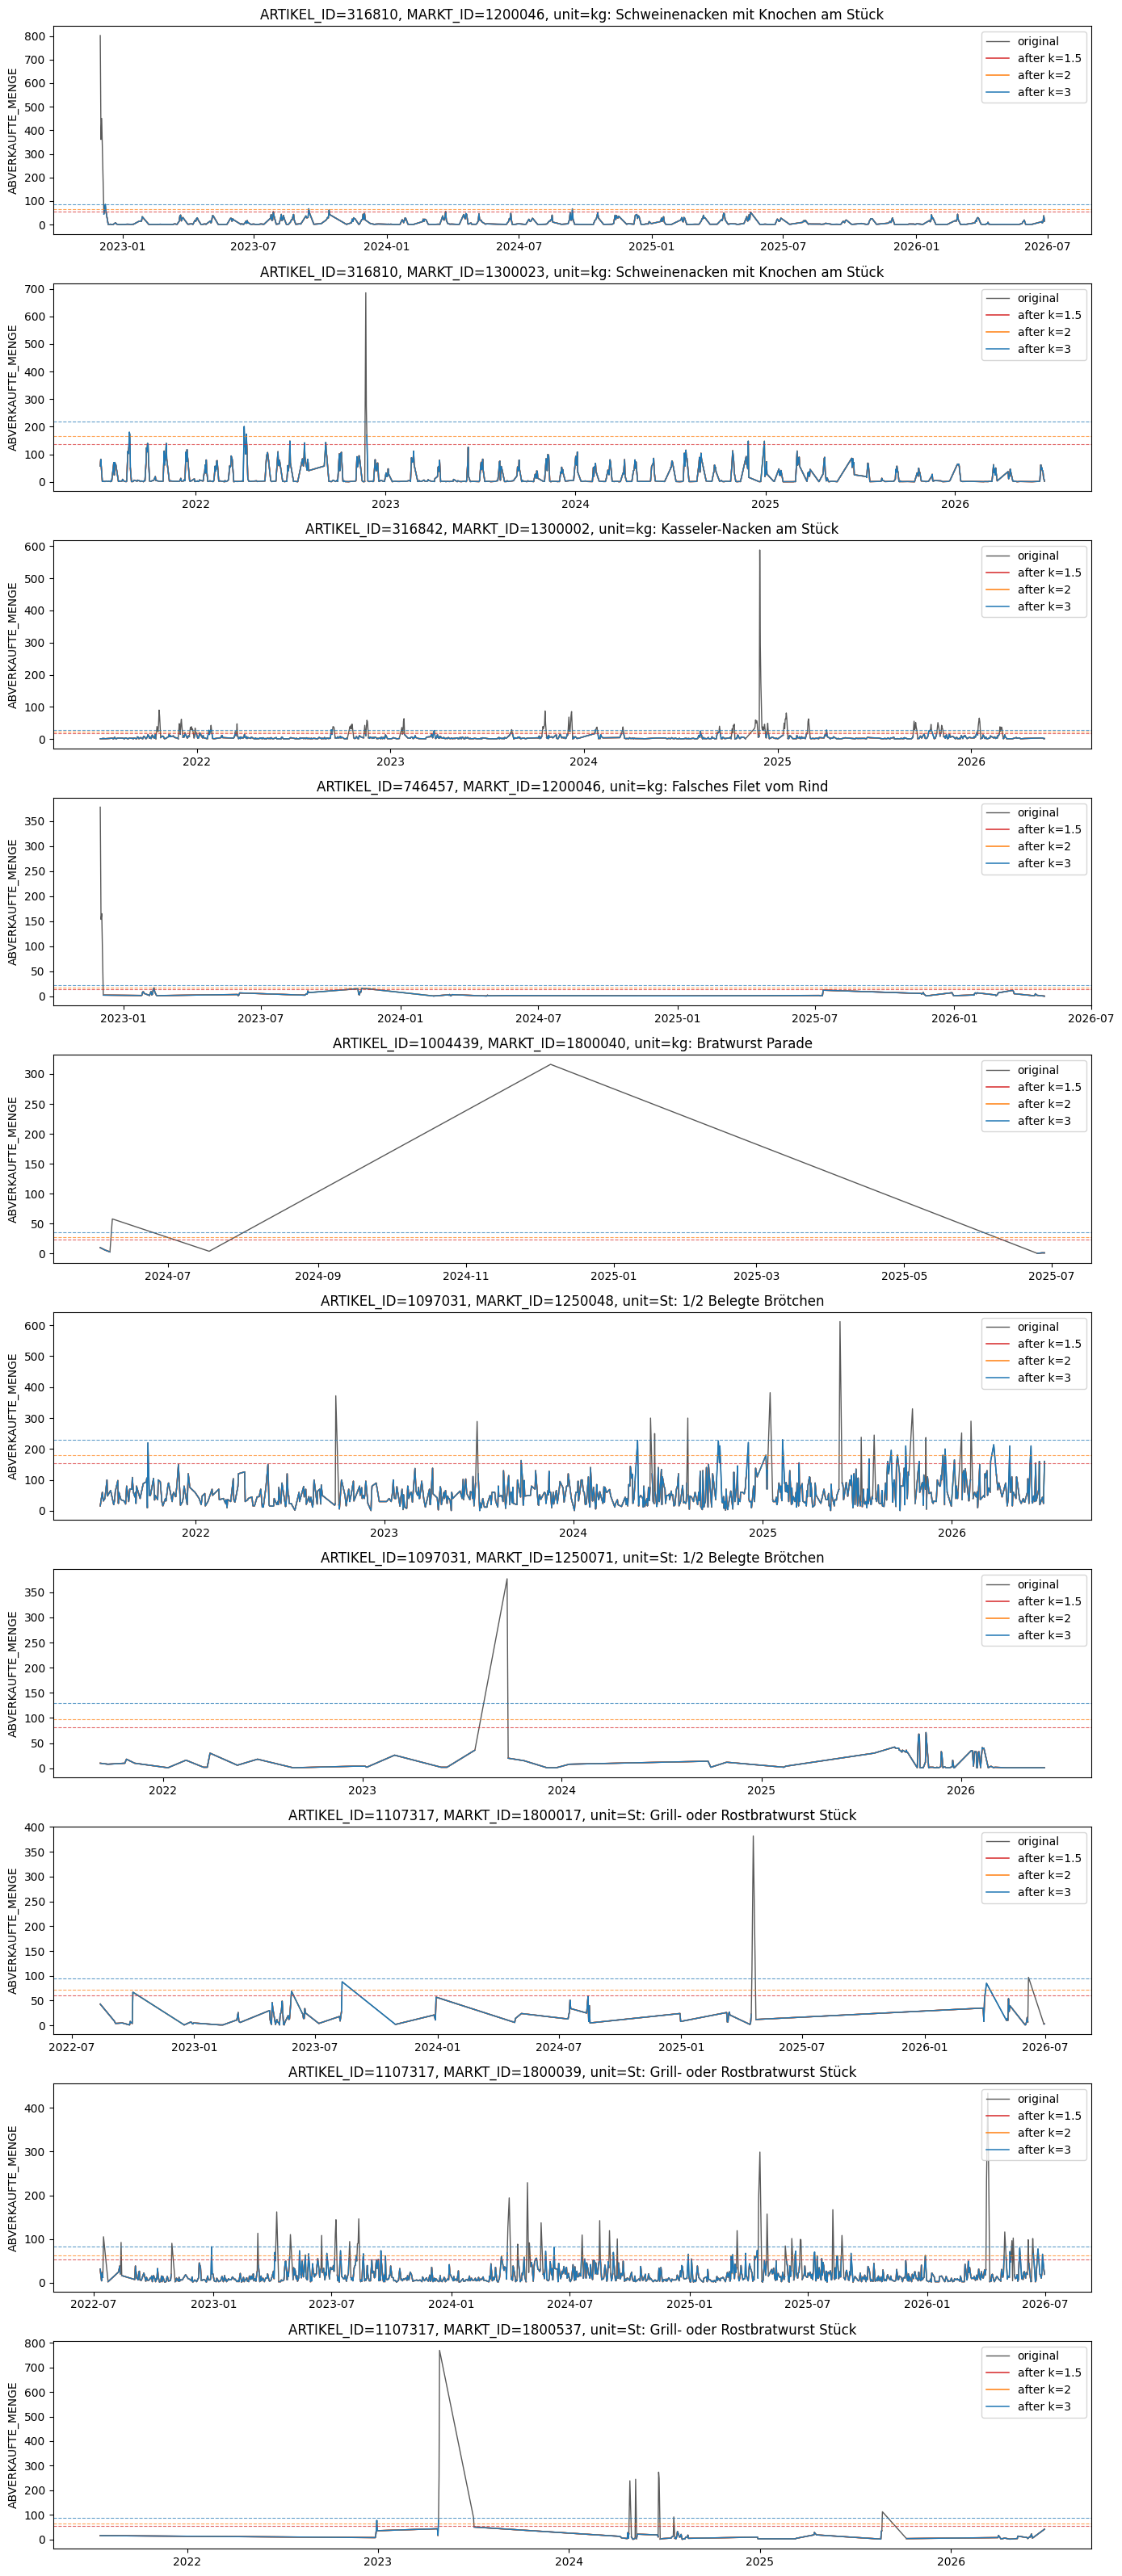

In [5]:
if top_outliers.empty:
    raise ValueError("No outliers found with k = 1.5.")

top_series = top_outliers[["ARTIKEL_ID", "MARKT_ID"]].copy()
con.register("top_series", top_series)

plot_df = con.execute(
    f"""
    SELECT
        s.ARTIKEL_ID,
        s.MARKT_ID,
        s.DATE_D AS DATE,
        s.{DEMAND_COL},
        s.ARTIKEL_BEZ,
        s.VERKAUFSEINHEIT,
        b.upper_k15,
        b.upper_k2,
        b.upper_k3
    FROM source s
    JOIN top_series ts USING (ARTIKEL_ID, MARKT_ID)
    JOIN bounds b USING (ARTIKEL_ID, MARKT_ID)
    ORDER BY s.ARTIKEL_ID, s.MARKT_ID, s.DATE_D
    """
).df()

plot_df["DATE"] = pd.to_datetime(plot_df["DATE"])
plot_df["after_k15"] = plot_df[DEMAND_COL].where(plot_df[DEMAND_COL] <= plot_df["upper_k15"])
plot_df["after_k2"] = plot_df[DEMAND_COL].where(plot_df[DEMAND_COL] <= plot_df["upper_k2"])
plot_df["after_k3"] = plot_df[DEMAND_COL].where(plot_df[DEMAND_COL] <= plot_df["upper_k3"])

groups = list(plot_df.groupby(["ARTIKEL_ID", "MARKT_ID"], sort=False))
fig, axes = plt.subplots(len(groups), 1, figsize=(14, 3.2 * len(groups)), sharex=False)
if len(groups) == 1:
    axes = [axes]

for ax, ((artikel_id, markt_id), df) in zip(axes, groups):
    title = str(df["ARTIKEL_BEZ"].iloc[0])[:90]
    unit = df["VERKAUFSEINHEIT"].iloc[0]

    ax.plot(df["DATE"], df[DEMAND_COL], color="0.35", linewidth=1.0, label="original")
    ax.plot(df["DATE"], df["after_k15"], color="tab:red", linewidth=1.1, label="after k=1.5")
    ax.plot(df["DATE"], df["after_k2"], color="tab:orange", linewidth=1.1, label="after k=2")
    ax.plot(df["DATE"], df["after_k3"], color="tab:blue", linewidth=1.1, label="after k=3")
    ax.axhline(df["upper_k15"].iloc[0], color="tab:red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(df["upper_k2"].iloc[0], color="tab:orange", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(df["upper_k3"].iloc[0], color="tab:blue", linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_title(f"ARTIKEL_ID={artikel_id}, MARKT_ID={markt_id}, unit={unit}: {title}")
    ax.set_ylabel(DEMAND_COL)
    ax.legend(loc="upper right")

plt.tight_layout()